In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def pareto_frontier(points, maximize=False):
    """
    Compute Pareto-optimal points.

    Parameters
    ----------
    points : np.ndarray, shape (n_points, n_objectives)
        Objective values.
    maximize : list[bool], optional
        True if objective is to be maximized, False if minimized.
        If None, all objectives are minimized.

    Returns
    -------
    is_pareto : np.ndarray (bool)
        Boolean mask of Pareto-optimal points.
    """
    points = np.asarray(points)
    n_points, n_obj = points.shape

    if maximize:
        maximize = [False] * n_obj
    else:
        maximize = [True] * n_obj
        

    # Convert maximization to minimization
    cost = points.copy()
    for i, max_ in enumerate(maximize):
        if max_:
            cost[:, i] = -cost[:, i]

    is_pareto = np.ones(n_points, dtype=bool)

    for i in range(n_points):
        if is_pareto[i]:
            # A point is dominated if another point is no worse in all objectives
            # and strictly better in at least one
            dominated = np.all(cost <= cost[i], axis=1) & np.any(cost < cost[i], axis=1)
            is_pareto[dominated] = False

    return is_pareto

In [3]:
def accuracy_results_to_df(results_list, dataset, sampling_method, rec_method):
    res = []
    for config in results_list:
        if sampling_method.endswith("_dp"):
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_mae = config["test_mae"]
        res.append((dataset, rec_method, sampling_method, e, b, test_mae))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "recsys", "sampling", "e", "b", "test_mae"])

def privacy_results_to_df(results_list, dataset, sampling_method):
    res = []
    for config in results_list:
        if sampling_method.endswith("_dp"):
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_bacc = config["test_bacc"]
        e_est = config["e_est"]
        res.append((dataset, sampling_method, e, b, test_bacc, e_est))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "sampling", "e", "b", "test_bacc", "e_est"])

In [49]:
DATASET = "ml1m"
PATH = DATASET + "/"

with open(PATH + "MetaMF.random_dp", "rb") as f:
    random_results = pkl.load(f)
    random_results_dp_df = accuracy_results_to_df(random_results, dataset="ml1m", sampling_method="random_dp", rec_method="MetaMF")
with open(PATH + "MetaMF.ister_dp", "rb") as f:
    ister_results = pkl.load(f)
    ister_results_dp_df = accuracy_results_to_df(ister_results, dataset="ml1m", sampling_method="ister_dp", rec_method="MetaMF")
with open(PATH + "MetaMF.random_del", "rb") as f:
    random_results = pkl.load(f)
    random_results_del_df = accuracy_results_to_df(random_results, dataset="ml1m", sampling_method="random_del", rec_method="MetaMF")
with open(PATH + "MetaMF.ister_del", "rb") as f:
    ister_results = pkl.load(f)
    ister_results_del_df = accuracy_results_to_df(ister_results, dataset="ml1m", sampling_method="ister_del", rec_method="MetaMF")
accuracy_results_df = pd.concat([random_results_dp_df, ister_results_dp_df, random_results_del_df, ister_results_del_df]).reset_index(drop=True)

with open(PATH + "NoMetaMF.random_dp", "rb") as f:
    random_results = pkl.load(f)
    random_results_dp_df = accuracy_results_to_df(random_results, dataset="ml1m", sampling_method="random_dp", rec_method="NoMetaMF")
with open(PATH + "NoMetaMF.ister_dp", "rb") as f:
    ister_results = pkl.load(f)
    ister_results_dp_df = accuracy_results_to_df(ister_results, dataset="ml1m", sampling_method="ister_dp", rec_method="NoMetaMF")
with open(PATH + "NoMetaMF.random_del", "rb") as f:
    random_results = pkl.load(f)
    random_results_del_df = accuracy_results_to_df(random_results, dataset="ml1m", sampling_method="random_del", rec_method="NoMetaMF")
with open(PATH + "NoMetaMF.ister_del", "rb") as f:
    ister_results = pkl.load(f)
    ister_results_del_df = accuracy_results_to_df(ister_results, dataset="ml1m", sampling_method="ister_del", rec_method="NoMetaMF")
accuracy_results_df = pd.concat([accuracy_results_df, random_results_dp_df, ister_results_dp_df, random_results_del_df, ister_results_del_df]).reset_index(drop=True)

PATH = DATASET + "/attacker_old/"
with open(PATH + "attacker.random_dp", "rb") as f:
    results = pkl.load(f)
    random_dp_df = privacy_results_to_df(results, DATASET, "random_dp")
with open(PATH + "attacker.ister_dp", "rb") as f:
    results = pkl.load(f)
    ister_dp_df = privacy_results_to_df(results, DATASET, "ister_dp")
with open(PATH + "attacker.random_del", "rb") as f:
    results = pkl.load(f)
    random_del_df = privacy_results_to_df(results, DATASET, "random_del")
with open(PATH + "attacker.ister_del", "rb") as f:
    results = pkl.load(f)
    ister_del_df = privacy_results_to_df(results, DATASET, "ister_del")
    
privacy_results_df = pd.concat([random_dp_df, ister_dp_df, random_del_df, ister_del_df]).reset_index(drop=True)

In [50]:
results_df = accuracy_results_df.merge(privacy_results_df, left_on=["dataset", "sampling", "e", "b"], right_on=["dataset", "sampling", "e", "b"])
results_df.head()

,dataset,recsys,sampling,e,b,test_mae,test_bacc,e_est
0,ml1m,MetaMF,random_dp,3.0,0.0,0.692591,0.729046,1.647626
1,ml1m,NoMetaMF,random_dp,3.0,0.0,0.710058,0.729046,1.647626
2,ml1m,MetaMF,random_dp,3.0,0.2,0.692166,0.735275,1.694304
3,ml1m,NoMetaMF,random_dp,3.0,0.2,0.705186,0.735275,1.694304
4,ml1m,MetaMF,random_dp,3.0,0.4,0.691901,0.709686,1.600061


C:\Users\pmuellner\AppData\Local\Temp\ipykernel_24776\1666763169.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nometamf_results_df["pareto_front"] = mask
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_24776\1666763169.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metamf_results_df["pareto_front"] = mask


Text(0, 0.5, 'MAE')

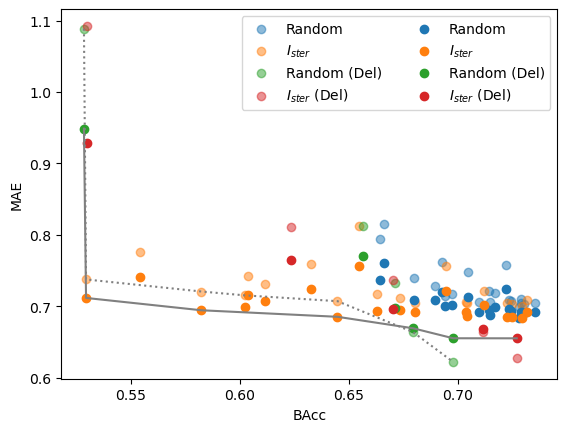

In [62]:
nometamf_results_df = results_df[results_df["recsys"] == "NoMetaMF"]

rand_dp_df = nometamf_results_df[nometamf_results_df["sampling"] == "random_dp"]
ister_dp_df = nometamf_results_df[nometamf_results_df["sampling"] == "ister_dp"]
plt.scatter(rand_dp_df["test_bacc"], rand_dp_df["test_mae"], c="C0", label="Random", alpha=0.5)
plt.scatter(ister_dp_df["test_bacc"], ister_dp_df["test_mae"], c="C1", label=r"$I_{ster}$", alpha=0.5)

rand_del_df = nometamf_results_df[nometamf_results_df["sampling"] == "random_del"]
ister_del_df = nometamf_results_df[nometamf_results_df["sampling"] == "ister_del"]
plt.scatter(rand_del_df["test_bacc"], rand_del_df["test_mae"], c="C2", label="Random (Del)", alpha=0.5)
plt.scatter(ister_del_df["test_bacc"], ister_del_df["test_mae"], c="C3", label=r"$I_{ster}$ (Del)", alpha=0.5)

pairs = nometamf_results_df[["test_bacc", "test_mae"]].values
mask = pareto_frontier(pairs, maximize=False)
nometamf_results_df["pareto_front"] = mask
frontier = np.array(sorted(pairs[mask], key=lambda t: t[0]))
plt.plot(frontier[:, 0], frontier[:, 1], c="gray", linestyle='dotted')

#################################################################################
metamf_results_df = results_df[results_df["recsys"] == "MetaMF"]

rand_dp_df = metamf_results_df[metamf_results_df["sampling"] == "random_dp"]
ister_dp_df = metamf_results_df[metamf_results_df["sampling"] == "ister_dp"]
plt.scatter(rand_dp_df["test_bacc"], rand_dp_df["test_mae"], c="C0", label="Random")
plt.scatter(ister_dp_df["test_bacc"], ister_dp_df["test_mae"], c="C1", label=r"$I_{ster}$")

rand_del_df = metamf_results_df[metamf_results_df["sampling"] == "random_del"]
ister_del_df = metamf_results_df[metamf_results_df["sampling"] == "ister_del"]
plt.scatter(rand_del_df["test_bacc"], rand_del_df["test_mae"], c="C2", label="Random (Del)")
plt.scatter(ister_del_df["test_bacc"], ister_del_df["test_mae"], c="C3", label=r"$I_{ster}$ (Del)")

pairs = metamf_results_df[["test_bacc", "test_mae"]].values
mask = pareto_frontier(pairs, maximize=False)
metamf_results_df["pareto_front"] = mask
frontier = np.array(sorted(pairs[mask], key=lambda t: t[0]))
plt.plot(frontier[:, 0], frontier[:, 1], c="gray", linestyle='-')

#plt.axhline(y=0.675, c="gray", linestyle="dotted")
#plt.axvline(x=0.66, c="gray", linestyle="dotted")

plt.legend(loc="upper right", ncol=2)
plt.xlabel("BAcc")
plt.ylabel("MAE")

Text(0, 0.5, 'MAE')

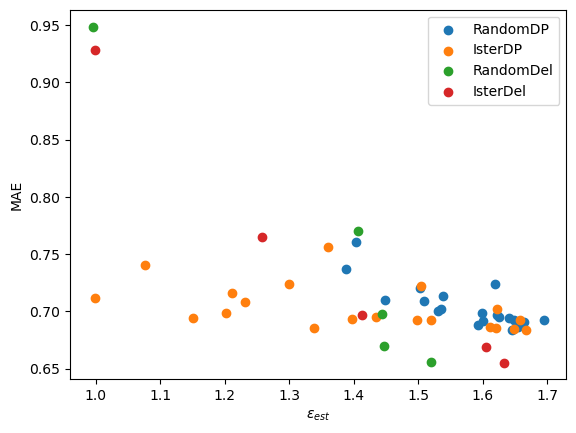

In [14]:
metamf_results_df = results_df[results_df["recsys"] == "MetaMF"]

rand_dp_df = metamf_results_df[metamf_results_df["sampling"] == "random_dp"]
ister_dp_df = metamf_results_df[metamf_results_df["sampling"] == "ister_dp"]
plt.scatter(rand_dp_df["e_est"], rand_dp_df["test_mae"], c="C0", label="RandomDP")
plt.scatter(ister_dp_df["e_est"], ister_dp_df["test_mae"], c="C1", label="IsterDP")

rand_del_df = metamf_results_df[metamf_results_df["sampling"] == "random_del"]
ister_del_df = metamf_results_df[metamf_results_df["sampling"] == "ister_del"]
plt.scatter(rand_del_df["e_est"], rand_del_df["test_mae"], c="C2", label="RandomDel")
plt.scatter(ister_del_df["e_est"], ister_del_df["test_mae"], c="C3", label="IsterDel")


#pairs = metamf_results_df[["e_est", "test_mae"]].values
#mask = pareto_frontier(pairs, maximize=False)
#metamf_results_df["pareto_front"] = mask
#frontier = np.array(sorted(pairs[mask], key=lambda t: t[0]))
#plt.plot(frontier[:, 0], frontier[:, 1], c="gray", linestyle='-')

plt.legend()
plt.xlabel(r"$\varepsilon_{est}$")
plt.ylabel("MAE")